# Machine Learning model

## 1. Importing packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

## 2. Loading dataset

In [2]:
df = pd.read_csv("C:/Users/HP/Desktop/GitHub/C_Programs./xxz_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  1000 non-null   int64  
 1   N          1000 non-null   int64  
 2   Kup        1000 non-null   int64  
 3   Jxy        1000 non-null   int64  
 4   Jz         1000 non-null   float64
 5   W          1000 non-null   float64
 6   seed       1000 non-null   int64  
 7   h_1        1000 non-null   float64
 8   h_2        1000 non-null   float64
 9   h_3        1000 non-null   float64
 10  h_4        1000 non-null   float64
 11  h_5        1000 non-null   float64
 12  h_6        1000 non-null   float64
 13  h_7        1000 non-null   float64
 14  h_8        1000 non-null   float64
 15  h_9        1000 non-null   float64
 16  h_10       1000 non-null   float64
 17  h_11       1000 non-null   float64
 18  h_12       1000 non-null   float64
 19  E0         1000 non-null   float64
 20  E1       

In [4]:
df.head()

,sample_id,N,Kup,Jxy,Jz,W,seed,h_1,h_2,h_3,...,h_6,h_7,h_8,h_9,h_10,h_11,h_12,E0,E1,gap
0,0,12,6,1,1.329887,5.423200,7584,-2.962427,-0.916087,0.326878,...,-0.203409,3.786657,5.344749,4.842598,-4.859811,5.140182,0.848228,-18.293148,-16.751156,1.541993
1,1,12,6,1,1.330100,5.327433,7587,3.861564,1.263776,-0.272005,...,-3.055466,-1.483266,-0.747080,4.612708,-4.731070,-5.319629,-4.335988,-17.531493,-16.325649,1.205844
2,2,12,6,1,1.330314,5.231849,7590,-0.021875,3.365966,-0.849595,...,4.658959,3.897342,3.840500,4.388162,-4.603714,-4.942850,1.129333,-19.027651,-18.921756,0.105896
3,3,12,6,1,1.330528,5.136082,7593,-3.765499,-4.882154,-1.406164,...,1.820600,-1.190169,-2.011829,4.168962,-4.478064,-4.576500,-3.874907,-12.823653,-12.494906,0.328747
4,4,12,6,1,1.330805,1.008209,7597,-0.374859,0.931902,0.246491,...,-0.363167,-0.202245,0.108153,0.781934,-0.868210,0.518243,-0.720703,-7.146831,-6.394283,0.752548


## \[$\color{blue}{\text{The data set is clean}}$\]

## 3. Feature selection

### 3.1. Feature importance

In [37]:
importances = pd.Series(model_E0.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importances.head(15))

h_std         0.490106
h_var         0.459788
h_abs_mean    0.011202
Jz            0.008622
W             0.003345
h_max         0.002609
h_1           0.002260
h_min         0.002147
h_3           0.002012
h_mean        0.001916
h_4           0.001905
h_5           0.001861
h_12          0.001787
h_9           0.001785
h_6           0.001736
dtype: float64


### 3.2. Vizualizing feature importance

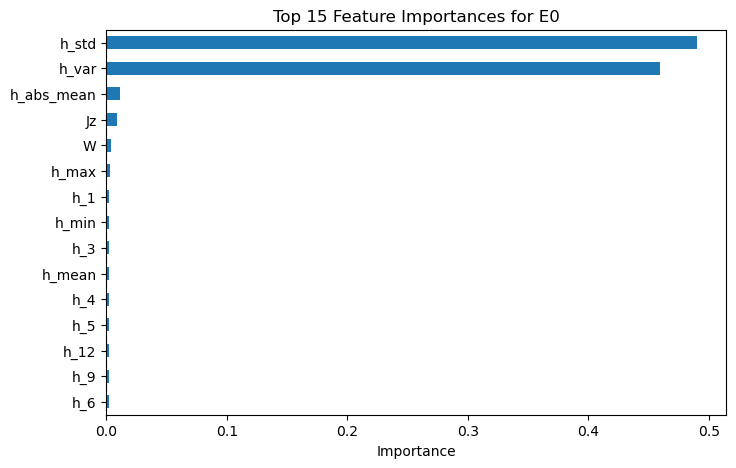

In [39]:
plt.figure(figsize=(8, 5))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances for E0")
plt.xlabel("Importance")
plt.show()

### 3.3. Enriching features

In [9]:
# Disorder column
h_cols = [col for col in df.columns if col.startswith("h_")]

# Enriching features 
df["h_mean"] = df[h_cols].mean(axis=1)  # mean disorder
df["h_std"] = df[h_cols].std(axis=1)    # Standard deviation
df["h_max"] = df[h_cols].max(axis=1)    # Maximum
df["h_min"] = df[h_cols].min(axis=1)    # Minimum
df["h_abs_mean"] = df[h_cols].abs().mean(axis=1)
df["h_var"] = df[h_cols].var(axis=1)    # variance

features = ["Jxy", "Jz", "W", "h_mean", "h_std", "h_max", "h_min", "h_abs_mean", "h_var"] + h_cols  # new features
X = df[features]  # enriched training set

# target 1 (easy to achieve)
y_E0 = df["E0"]

# target (difficult to achieve)
y_gap = df["gap"]  

## 4. Instantiate model for E0

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_E0, test_size=0.2, random_state=42
)

# Instantiate model with random forest
model_E0 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# training the model
model_E0.fit(X_train, y_train)

#  predict
y_pred = model_E0.predict(X_test)

## 5. Scoring the model

In [74]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Model for E0 ===")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R2   : {r2:.6f}")

=== Model for E0 ===
MAE  : 0.588864
RMSE : 0.809713
R2   : 0.956818


## 6. True values versus predicted values

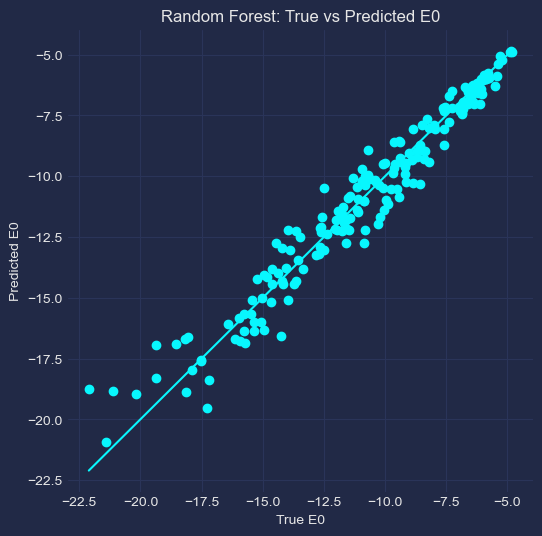

In [77]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("True E0")
plt.ylabel("Predicted E0")
plt.title("Random Forest: True vs Predicted E0")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

## 7. Instantiate model for the gap

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_gap, test_size=0.3, random_state=42
)

# Instantiate model for the gap
model_gap = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# training the model for gap
model_gap.fit(X_train, y_train)

y_pred_gap = model_gap.predict(X_test)


## 8. Scoring the model for the gap

In [95]:
mae_gap = mean_absolute_error(y_test, y_pred_gap)
rmse_gap = np.sqrt(mean_squared_error(y_test, y_pred_gap))
r2_gap = r2_score(y_test, y_pred_gap)

print("=== Model for gap ===")
print(f"MAE  : {mae_gap:.6f}")
print(f"RMSE : {rmse_gap:.6f}")
print(f"R2   : {r2_gap:.6f}")

=== Model for gap ===
MAE  : 0.335099
RMSE : 0.447804
R2   : -0.032987


## \[$\color{blue}{\text{Very bad model for the gap  (to be improved)}}$\]

## 9. Exporting the models

In [23]:
import joblib

joblib.dump(model_E0, "rf_model_E0.pkl")

['rf_model_E0.pkl']

In [25]:
import joblib

joblib.dump(X.columns.tolist(), "feature_order.pkl")

['feature_order.pkl']